##**Model to predict if a customer will subscribe to a term deposit or not**




In [ ]:
#import warnings

#warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd


# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)



##Loading the data

In [ ]:
# mount Google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
pdata = pd.read_csv('/content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/term-deposit-marketing-2020.csv')


In [ ]:
data = pdata.copy()

## Data preprocessing

In [ ]:
# Making a list of all categorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64
--------------------------------------------------
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64
--------------------------------------------------
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64
--------------------------------------------------
default
no     39191
yes      809
Name: count, dtype: int64
--------------------------------------------------
housing
yes    24031
no     15969
Name: count, dtype: int64
--------------------------------------------------
loan
no     33070
yes     6930
Name: count, dtype: int64
--------------------------------------------------
contact
cellular     24

- job: This shows the distribution of job types among the customers. 'blue-collar', 'management', and 'technician' are the most frequent job categories, while 'student' and 'unknown' are the least frequent. The presence of 'unknown' indicates some missing or unclassified job information.

- marital: The majority of customers are 'married', followed by 'single', and then 'divorced'. This indicates a strong prevalence of married individuals in the dataset.

- education: 'secondary' education is the most common, followed by 'tertiary' and 'primary'. There's also an 'unknown' category for education, similar to 'job'.

- default: The vast majority of customers (39191) have 'no' credit in default, with a very small number (809) having 'yes'. This indicates a highly imbalanced distribution, which is important to consider for modeling.

- housing: More customers (24031) have a 'yes' for a housing loan compared to 'no' (15969).

- loan: The majority of customers (33070) do not have a personal loan ('no'), while a smaller group (6930) does ('yes').

- contact: 'cellular' is the most common contact type, followed by a significant number of 'unknown' contact types, and then 'telephone'. The 'unknown' contact type is a notable category.

- month: 'may' is by far the month with the most contacts, followed by 'jul' and 'aug'. 'dec', 'oct', and 'mar' have very few contacts, suggesting seasonality or specific campaign periods.

- y (target variable): This is the target variable indicating whether the client subscribed to a term deposit. A large majority of customers (37104) did 'no' subscribe, while a much smaller number (2896) did 'yes' subscribe. This shows a significant class imbalance, where the 'yes' class is the minority class. This imbalance is critical and will need to be addressed during model training to avoid biased predictions.

## 1. Split dataset into features and target

In [ ]:
target_column = 'y'
X = data.drop(columns=[target_column])
y = data[target_column]

print(X.head())
print(y.shape, y)

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  
0  unknown    5   may       261         1  
1  unknown    5   may       151         1  
2  unknown    5   may        76         1  
3  unknown    5   may        92         1  
4  unknown    5   may       198         1  
(40000,) 0         no
1         no
2         no
3         no
4         no
        ... 
39995     no
39996    yes
39997    yes
39998     no
39999     no
Name: y, Length: 40000, dtype: object


##2. Convert non-numeric data into numeric

In [ ]:
def replace_binary_columns(df):
    df = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object' and len(df[col].value_counts()) == 2:
            values = df[col].unique()
            # Assign the result of replace back to the column to avoid FutureWarning
            df[col] = df[col].replace({'yes': 1, 'no': 0})

    return df

In [ ]:
X = replace_binary_columns(X)
X = pd.get_dummies(X, columns = ['job', 'marital', 'education', 'contact', 'month'])

/tmp/ipykernel_219/2052112342.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes': 1, 'no': 0})
/tmp/ipykernel_219/2052112342.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes': 1, 'no': 0})
/tmp/ipykernel_219/2052112342.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('futu

In [ ]:
y = y.replace('yes', 1)
y = y.replace('no', 0)

/tmp/ipykernel_219/1926681711.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace('no', 0)


In [ ]:
X.head()

,age,default,balance,housing,loan,day,duration,campaign,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,58,0,2143,1,0,5,261,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,44,0,29,1,0,5,151,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,33,0,2,1,1,5,76,1,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,47,0,1506,1,0,5,92,1,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,33,0,1,0,0,5,198,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False


In [ ]:
y.head()

,y
0,0
1,0
2,0
3,0
4,0


In [ ]:
print(y.value_counts(), y.value_counts()[0] / len(y))

y
0    37104
1     2896
Name: count, dtype: int64 0.9276


##3. Split the data into train and test

In [ ]:
# Resampling due to unbalanced data
from collections import Counter # Import Counter
rus = RandomUnderSampler(sampling_strategy = 'majority')
X_resampled, y_resampled = rus.fit_resample (X, y)
# summarize class distribution

print(len(X_resampled), len(y_resampled))
print(Counter(y_resampled))

5792 5792
Counter({0: 2896, 1: 2896})


##4. Scale the feature values to a uniform range

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Instantiate MinMaxScaler and use it to rescale X_train and X_test
# scaler = MinMaxScaler()
scaler = StandardScaler()
X_train_rescaled = scaler.fit_transform(X_train)
X_test_rescaled = scaler.transform(X_test)

##5. Label encoding

In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
data = data[['month', 'loan', 'housing', 'education', 'marital' , 'job', 'y']]
for col in data.columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

data.head()

,month,loan,housing,education,marital,job,y
0,8,0,1,2,1,4,0
1,8,0,1,1,2,9,0
2,8,1,1,1,1,2,0
3,8,0,1,3,1,1,0
4,8,0,0,3,2,11,0


In [ ]:
# checking for age range
data.head()

,month,loan,housing,education,marital,job,y
0,8,0,1,2,1,4,0
1,8,0,1,1,2,9,0
2,8,1,1,1,1,2,0
3,8,0,1,3,1,1,0
4,8,0,0,3,2,11,0


##Correlation matrix

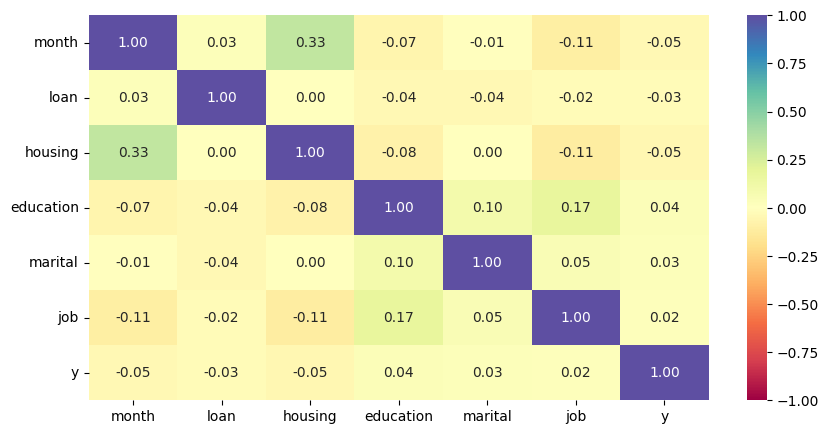

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

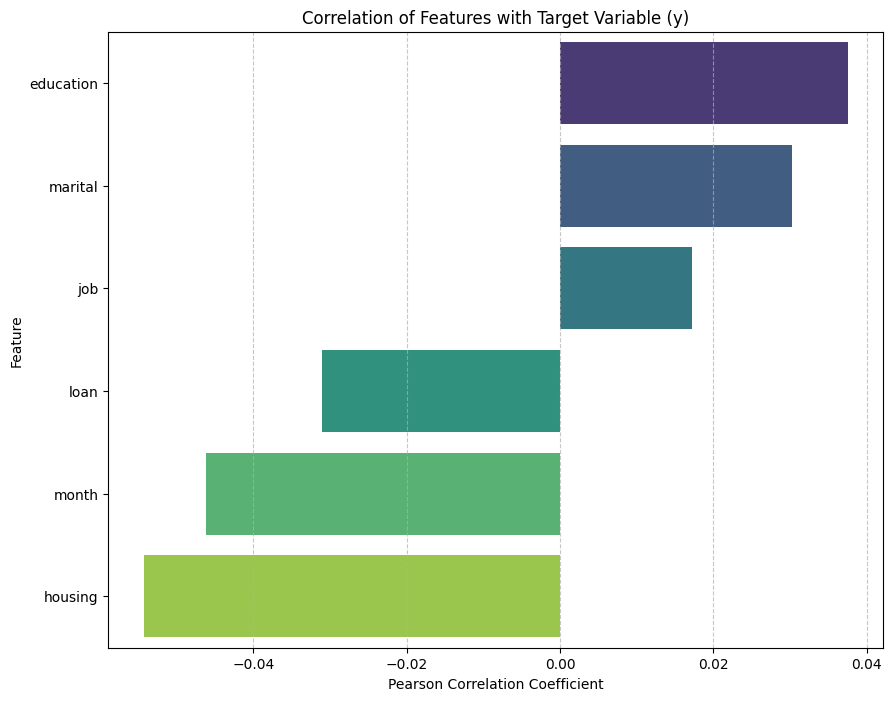

In [ ]:
# Calculate correlations with the target variable 'y'
correlations_with_y = data.corr(numeric_only=True)['y'].sort_values(ascending=False)

# Drop the correlation of 'y' with itself
correlations_with_y = correlations_with_y.drop('y')

# Create a DataFrame for plotting
correlations_df = pd.DataFrame(correlations_with_y).reset_index()
correlations_df.columns = ['Feature', 'Correlation']

# Plotting the correlations
plt.figure(figsize=(10, 8))
sns.barplot(x='Correlation', y='Feature', data=correlations_df, palette='viridis', hue='Feature', legend=False)
plt.title('Correlation of Features with Target Variable (y)')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Positive Correlations:**
Features like duration show the strongest positive correlation with 'y'. This suggests that a longer last contact duration is associated with a higher likelihood of subscription. education, marital, balance, and job also show small positive correlations.

**Negative Correlations:**
Features such as housing, month, campaign, loan, age, day, default, and contact show negative correlations. For instance, a higher campaign number (more contacts) is negatively correlated with subscription, implying diminishing returns from excessive contacts. Having a housing loan or a personal loan is also negatively correlated with subscription.

**Based on the correlation matrix with 'y', features with very low absolute correlation are generally less impactful on the target variable.** Consider dropping the following features:

- contact: Correlation of -0.002714
- default: Correlation of -0.008206
- day: Correlation of -0.008699

These features show very little linear relationship with the target variable y (whether a customer subscribes to a term deposit). Removing them could help reduce model complexity without significantly impacting performance.

In [ ]:
import os
import pandas as pd

# Define the directory path where data will be saved
data_dir = '/content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB'

# Create the directory if it does not exist
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Convert scaled numpy arrays back to DataFrames with original column names and index
X_train_rescaled_df = pd.DataFrame(X_train_rescaled, columns=X_train.columns, index=X_train.index)
X_test_rescaled_df = pd.DataFrame(X_test_rescaled, columns=X_test.columns, index=X_test.index)

# Merge features and target for saving
train_data_to_save = X_train_rescaled_df.merge(y_train.rename('y'), left_index=True, right_index=True)
test_data_to_save = X_test_rescaled_df.merge(y_test.rename('y'), left_index=True, right_index=True)

# Save the processed data
train_data_to_save.to_csv(os.path.join(data_dir, 'undersampled_scaled_train.csv'), index=False)
test_data_to_save.to_csv(os.path.join(data_dir, 'undersampled_scaled_test.csv'), index=False)

print(f"Undersampled and scaled training data saved to {os.path.join(data_dir, 'undersampled_scaled_train.csv')}")
print(f"Undersampled and scaled testing data saved to {os.path.join(data_dir, 'undersampled_scaled_test.csv')}")

Undersampled and scaled training data saved to /content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/undersampled_scaled_train.csv
Undersampled and scaled testing data saved to /content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/undersampled_scaled_test.csv


In [ ]:
import joblib
import os

# Define the path for the preprocessor
preprocessor_path = "/content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/preprocessor.joblib"

# Ensure the directory exists
os.makedirs(os.path.dirname(preprocessor_path), exist_ok=True)

# Save the scaler object (which represents your preprocessing pipeline) using joblib
joblib.dump(scaler, preprocessor_path)

print(f"Preprocessing pipeline (StandardScaler) saved to: {preprocessor_path}")

Preprocessing pipeline (StandardScaler) saved to: /content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/preprocessor.joblib


## Preprocessing Steps Summary

| Feature | Previous Data Type | Encoding Strategy | Current Data Type (for X/y used in modeling) |
|:----------|:-------------------|:----------------------------------------------------------------------|:--------------------------------------------|
| `age` | `int64` | None | `float64` (after scaling) |
| `job` | `object` | One-Hot Encoding | `float64` (after one-hot encoding and scaling) |
| `marital` | `object` | One-Hot Encoding | `float64` (after one-hot encoding and scaling) |
| `education`| `object` | One-Hot Encoding | `float64` (after one-hot encoding and scaling) |
| `default` | `object` ('no'/'yes')| Binary Encoding (0/1) | `float64` (after scaling) |
| `balance` | `int64` | None | `float64` (after scaling) |
| `housing` | `object` ('no'/'yes')| Binary Encoding (0/1) | `float64` (after scaling) |
| `loan` | `object` ('no'/'yes')| Binary Encoding (0/1) | `float64` (after scaling) |
| `contact` | `object` | One-Hot Encoding | `float64` (after one-hot encoding and scaling) |
| `day` | `int64` | None | `float64` (after scaling) |
| `month` | `object` | One-Hot Encoding | `float64` (after one-hot encoding and scaling) |
| `duration`| `int64` | None | `float64` (after scaling) |
| `campaign`| `int64` | None | `float64` (after scaling) |
| `y` | `object` ('no'/'yes')| Binary Encoding (0/1) | `int64` |

**Additional Notes:**
- **Undersampling**: The data was undersampled using `RandomUnderSampler` to address class imbalance.
- **Scaling**: All numerical and encoded features in `X_train` and `X_test` were scaled using `StandardScaler`.